In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
#First we have to find the missing or null values in the data
df = pd.read_csv('/retail_sales_dataset.csv')
df.head()

,Date,Product,Category,Region,Quantity,Price,Sales
0,2023-04-13,Tablet,Electronics,North,3,56343,169029
1,2023-07-08,Smartwatch,Accessories,East,2,18850,37700
2,2023-08-03,Headphones,Accessories,East,5,46131,230655
3,2023-12-26,Monitor,Electronics,East,5,2769,13845
4,2023-12-10,Tablet,Electronics,South,2,7311,14622


In [4]:
df.columns

Index(['Date', 'Product', 'Category', 'Region', 'Quantity', 'Price', 'Sales'], dtype='object')

In [5]:
df.isnull().sum()

,0
Date,0
Product,0
Category,0
Region,0
Quantity,0
Price,0
Sales,0


In [6]:
#Since there is no missing value in the dataset so we can perform the further operations

In [13]:
#What is the total revenue generated from sales?
total_revenue = df['Sales'].sum()

print("\nTotal Revenue Generated from Sales:")
print(total_revenue)


Total Revenue Generated from Sales:
26361332


In [15]:
#Which product category generates the highest revenue?
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("Revenue by Category:")
print(category_revenue)

Revenue by Category:
Category
Electronics    16646055
Accessories     6708387
Office          3006890
Name: Sales, dtype: int64


In [18]:
# Which region contributes the most to sales?
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Sales by Region:")
print(region_sales)


Sales by Region:
Region
North    8553333
West     6400391
South    5871245
East     5536363
Name: Sales, dtype: int64


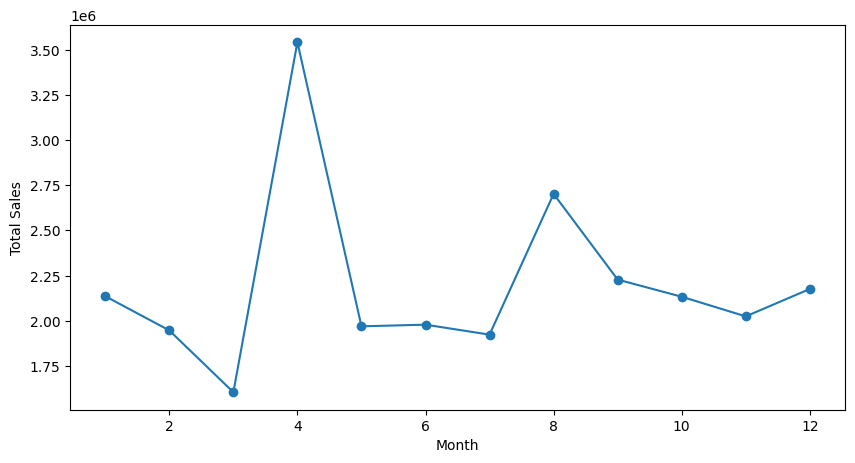

In [21]:
#How do monthly sales trends change over time?
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

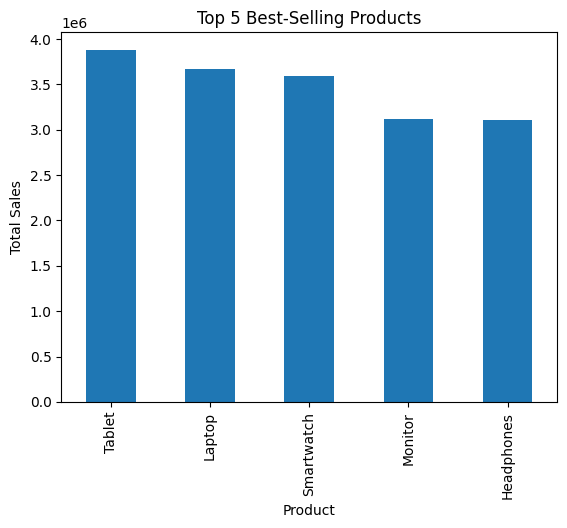

In [23]:
#What are the top 5 best■selling products?
top_products = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)

top_products.plot(kind='bar')

plt.title("Top 5 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

Region
North    8553333
West     6400391
South    5871245
East     5536363
Name: Sales, dtype: int64


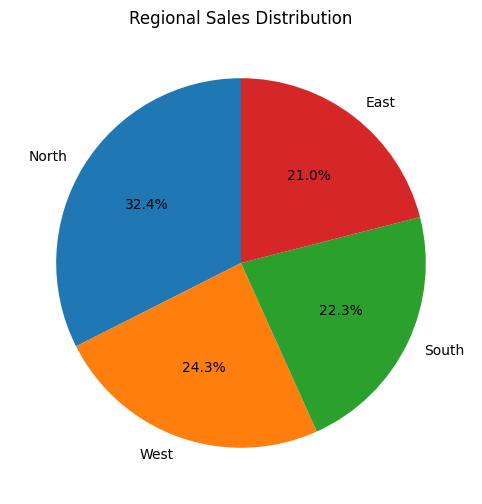

In [24]:
#Pie Chart – Regional sales distribution
regional_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)


plt.figure(figsize=(8,6))

plt.pie(region_sales,
        labels=region_sales.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Regional Sales Distribution")

plt.show()